In [34]:
from src import *
from myutils import *

# @email_notify('hcnzj@qq.com')
def main():
    with RaspiLED() as led, EasyDcam() as dcam:
        dcam.ez_exposure_time(500e-6)
        dcam.ez_roi(**SPADE.ROI)
        data = []
        for b in tqdm(np.arange(101)):
            led.brightness(20 * b)
            sleep(1)
            dcam.buf_alloc(100)
            dcam.cap_snapshot()
            dcam.ez_wait_capture()
            data_ = [dcam.ez_read_buf(i)[0] for i in range(100)]
            data.append(data_)

    np.save('led.npy', np.array(data))

In [35]:
main()

qCMOS found, current sensor temperature is -37.0.


100%|██████████| 101/101 [02:07<00:00,  1.26s/it]


EasyDcam exited
RaspiLED exited


In [42]:
data = np.load('led.npy')
data2 = np.load('led_di.npy')

In [43]:
data_ = []
data2_ = []

In [44]:
for i in range(101):
    data_.append(data[i].astype(float).mean())
    data2_.append(data2[i].astype(float).mean())

In [47]:
data_ = (np.array(data_) - 200) * 0.11
data2_ = (np.array(data2_) - 200) * 0.11

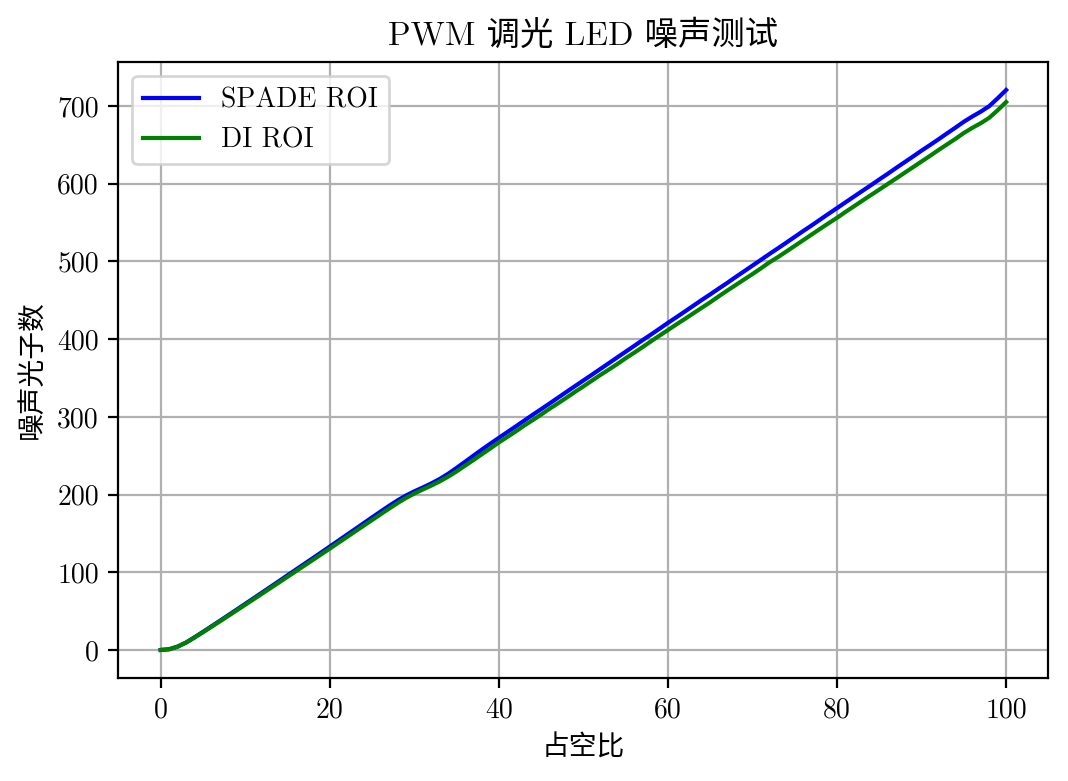

In [50]:
plot(data_, label='SPADE ROI')
plot(data2_, label='DI ROI')

plot(xlabel='占空比', ylabel='噪声光子数', title='PWM 调光 LED 噪声测试')

In [ ]:
data_